# Cattle Disease Risk Prediction using Machine Learning



| Area | Explaination |
|------|----------|
| Model | **LightGBM** — faster, native class-weighting, early stopping |
| Features | **28 features** (8 engineered: wildlife interaction, biosecurity risk, seasonal flags, etc.) |
| Class Imbalance | **`scale_pos_weight=8.26`** penalises minority class misclassification at the loss level |
| Threshold Tuning |**F1-optimised on held-out validation split** (no leakage) |
| Validation | **5-fold stratified cross-validation** + held-out test |
| Explainability | Feature importances + **SHAP** summary plot |


## 1. Setup

In [1]:
# Library & Environment Setup
import os
import warnings

# Suppressing warnings is crucial for a clean notebook presentation to stakeholders.
# Pandas and Scikit-Learn can be notoriously noisy with deprecation warnings.
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make all our charts look clean and organised by default
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.autolayout': True})

# for Machine Learning- Preprocessing & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_curve, f1_score
)

import lightgbm as lgb
import shap

#  Global Configurations
# Setting a global random state is absolutely non-negotiable in data science.
# If we don't lock this down, our train/test splits and model weights will shift 
# every time we run the notebook, making our results impossible to reproduce.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment successfully initialized. All libraries loaded.")

Environment successfully initialized. All libraries loaded.


## 2. Load Data

In [2]:
#  Step 0: Data Ingestion & Imbalance Check 
# Always check if the file actually exists in the directory before loading. 
# It saves a lot of headaches if we move this notebook around later.
file_path = "farm_data.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully! Shape: {df.shape[0]:,} rows and {df.shape[1]} columns.\n")
        
else:
    print(f"Error: Could not find '{file_path}'. Double-check working directory!")


Dataset loaded successfully! Shape: 10,000 rows and 27 columns.



## 3. Exploratory Data Analysis

We will now go through the dataset and try to figure out relations and correlations among the multiple columns that exists in the data and try to figure out what works best for us to predict and control further disease outbreaks.

In [3]:
# Step 1: Baseline Data Sanity Check 
# Before we do any feature engineering or modeling, we have to know exactly 
# what we are working with. Questions like, Are we missing half our data? Are numerical columns 
# accidentally loading as strings? How bad is our class imbalance?

print(f"Dataset Shape: {df.shape[0]:,} rows | {df.shape[1]} columns\n")

# Combining data types and missing value counts into a single, clean summary table.
# This is way easier to read than standard print statements, especially 
# when we have dozens of features.
data_summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isna().sum(),
    'Missing %': (df.isna().sum() / len(df) * 100).round(2)
})

# Sorting by missing values to instantly see which columns are going to give us problems
print("Column Summary (Top 10 with most missing values):")
display(data_summary.sort_values('Missing Values', ascending=False).head(10))

print("\n" + "="*40 + "\n")

# CRITICAL: The Target Distribution.
# If this is 50/50, we have an easy day. If it's 95/5, we are going to need 
# specialized techniques (like scale_pos_weight or PR-AUC metrics) because 
# a standard model will just predict "Negative" every time and claim very high accuracy.
print("Target Variable Distribution :")
# Multiplying by 100 to get readable percentages instead of raw decimals
target_dist = df["Test_Result"].value_counts(normalize=True) * 100
for outcome, pct in target_dist.items():
    print(f" - {outcome}: {pct:.2f}%")

Dataset Shape: 10,000 rows | 27 columns

Column Summary (Top 10 with most missing values):


,Data Type,Missing Values,Missing %
Subscribed_To_Newsletter,object,2120,21.2
Farm_Phone_Number,object,1420,14.2
Farm_Street_Address,object,1300,13.0
Farm_ID,object,0,0.0
Animal_Age_Months,int64,0,0.0
Proximity_To_Known_Diseased_Wildlife_Sett_Km,float64,0,0.0
Diseased_Wildlife_Density_Score_Local,object,0,0.0
Avg_Temperature_3M_Prior_C,float64,0,0.0
Avg_Rainfall_3M_Prior_MM,int64,0,0.0
Has_Disease_History_Farm,bool,0,0.0




Target Variable Distribution :
 - Negative: 89.20%
 - Positive: 10.80%


This initial diagnostic instantly exposes the severity of our class imbalance, proving that standard accuracy metrics will be highly deceptive and mandate the use of precision-recall tracking. Simultaneously, mapping our missing data gaps upfront dictates exactly where we need to apply robust imputation strategies before feeding anything into the model.

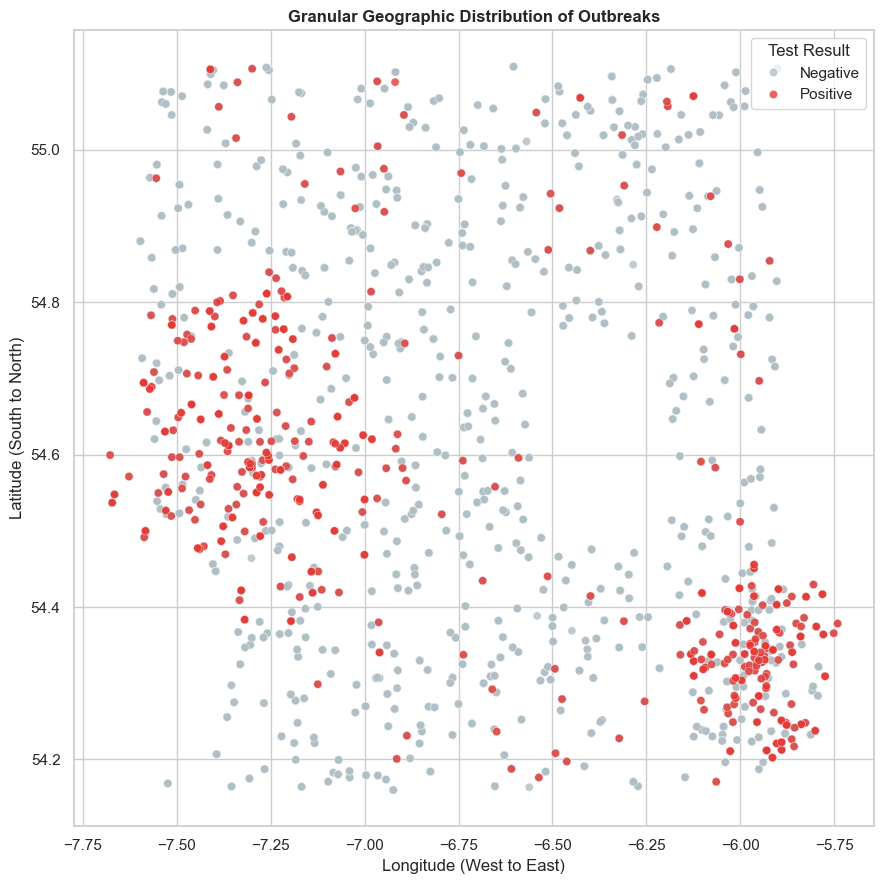

In [4]:
# Geographic Scatter Plot
# Grid heatmaps are great for high-level zones, but ground teams often just 
# want to see the literal "pins on the map". 

# We sample the data to prevent the plot from becoming a solid, unreadable block of color.
df_sample = df.sample(min(len(df), 5000), random_state=RANDOM_STATE).copy()

# Z-Order Overplotting.
# Because healthy farms massively outnumber diseased farms, plotting them randomly 
# guarantees the blue negative dots will physically cover up the positive outbreaks.
# By sorting the dataframe, we guarantee the 'Positive' cases are plotted LAST (on top).
df_sample['Test_Result'] = pd.Categorical(df_sample['Test_Result'], categories=['Negative', 'Positive'], ordered=True)
df_sample = df_sample.sort_values('Test_Result')

plt.figure(figsize=(9, 9)) # Square figure usually looks more like a natural map

# Custom palette: Let the healthy farms fade into the background as a soft gray/blue, 
# and make the actual outbreaks scream at the user in bright red.
custom_palette = {"Negative": "#B0BEC5", "Positive": "#E53935"}

sns.scatterplot(
    data=df_sample,
    x="Farm_Location_Lon",
    y="Farm_Location_Lat",
    hue="Test_Result",
    palette=custom_palette,
    alpha=0.8, # Just enough transparency to see dense overlapping clusters
    s=35,      # Slightly larger dots so the red really pops
    edgecolor="white", # Adds a tiny border to separate overlapping dots
    linewidth=0.3
)

plt.title("Granular Geographic Distribution of Outbreaks", fontweight='bold')
plt.xlabel("Longitude (West to East)")
plt.ylabel("Latitude (South to North)")

# Keep the legend clean and out of the way of the data
plt.legend(title="Test Result", loc="upper right")
plt.tight_layout()
plt.savefig('GeoDistribution-Outbreak.png')
plt.show()

Mapping the exact coordinates exposes physical transmission corridors and immediate spillover risks between neighboring properties that a high-level grid might miss. This granular view allows field teams to draw highly precise, localized containment perimeters instead of relying on broad, economically damaging regional lockdowns.

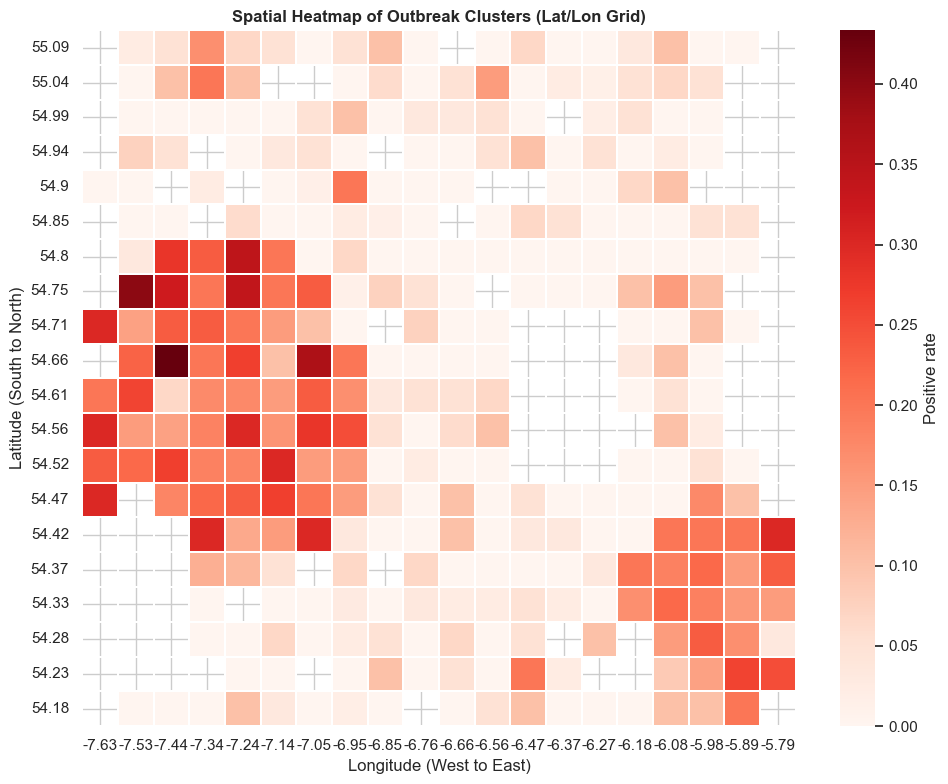

In [5]:
#  Spatial Risk Mapping 
# to spot regional outbreaks. By simply carving the map into a 2D grid based 
# on Latitude and Longitude,to visualize geographic hot zones.

n_bins = 20
df_spatial = df.copy()

# Chop the coordinates into a 20x20 grid
df_spatial["lat_bin"] = pd.cut(df_spatial["Farm_Location_Lat"], bins=n_bins)
df_spatial["lon_bin"] = pd.cut(df_spatial["Farm_Location_Lon"], bins=n_bins)

# Calculating the positive test rate for every specific square on our grid
heat = (
    df_spatial.groupby(["lat_bin", "lon_bin"])["Test_Result"]
    .apply(lambda s: (s == "Positive").mean())
    .unstack()
)

# Clean up the axis labels by grabbing just the midpoint of the pandas interval.
# Otherwise, the axes will be flooded with messy brackets like "(52.123, 52.456]".
heat.index = [round(interval.mid, 2) for interval in heat.index]
heat.columns = [round(interval.mid, 2) for interval in heat.columns]

plt.figure(figsize=(10, 8))

# Plot the grid. Any grid cells with absolutely zero farms will just show up as blank/white.
ax = sns.heatmap(
    heat,
    cmap="Reds",
    cbar_kws={"label": "Positive rate"},
    linewidths=0.1
)

# By default, heatmaps plot the lowest value (lowest latitude/South) 
# at the top of the chart. We invert the Y-axis so North is actually pointing up!
ax.invert_yaxis()

plt.title("Spatial Heatmap of Outbreak Clusters (Lat/Lon Grid)", fontweight='bold')
plt.xlabel("Longitude (West to East)")
plt.ylabel("Latitude (South to North)")
plt.tight_layout()
plt.savefig('HeatMap-OutbreakCluster.png')
plt.show()

This spatial grid visually isolates active disease clusters, proving that outbreaks are highly localized rather than randomly distributed across the country. Pinpointing these specific geographic "hot zones" allows us to establish targeted containment cordons and deploy veterinary
resources exactly where the infection is actively spreading.

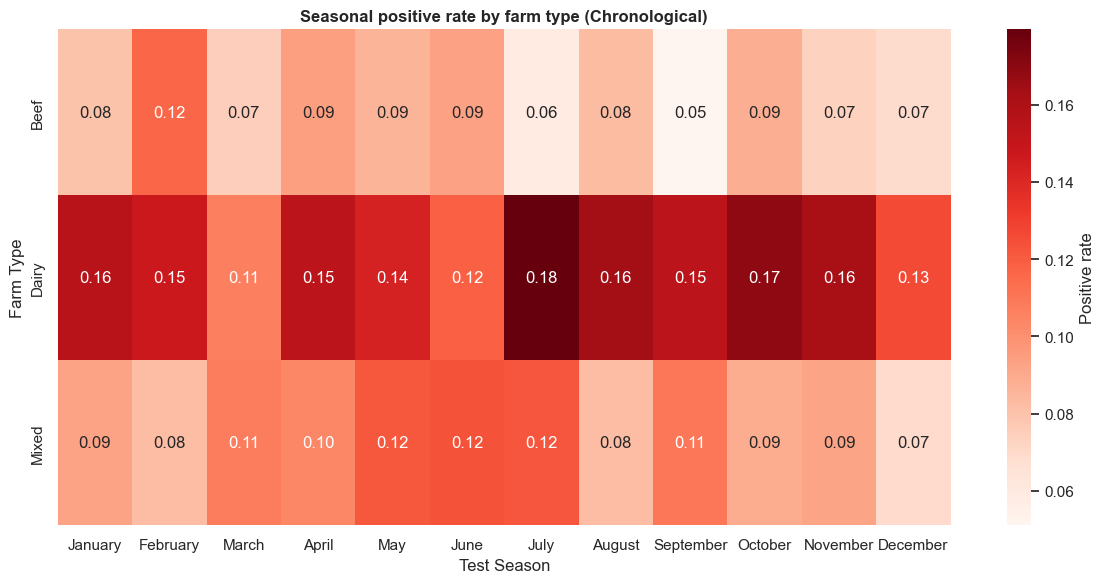

In [6]:
# Farm Type vs. Season 
# We know different farm types (Dairy, Beef, etc.) have entirely different 
# operational calendars. We need to see if their disease risk fluctuates 
# based on the time of year (e.g., bringing cows indoors for Winter).

# Calculate the positive hit rate for every combination of Season and Farm Type
season_type = (
    df.groupby(["Test_Season", "Farm_Type"])["Test_Result"]
      .apply(lambda s: (s == "Positive").mean())
      .reset_index(name="positive_rate")
)

# Pivot the data so Farm Types are rows and Seasons are columns
pivot_season_type = season_type.pivot(
    index="Farm_Type",
    columns="Test_Season",
    values="positive_rate"
)

# Pandas sorts columns alphabetically by default. 
# We need to force chronological order so the heatmap actually reads like a calendar.
chronological_order = ['January','February','March','April','May','June',
                       'July','August','September','October','November','December']

# Only reindex with the months that actually exist in our pivot table
valid_cols = [m for m in chronological_order if m in pivot_season_type.columns]
pivot_season_type = pivot_season_type[valid_cols]

# Time to visualize. This tells the us exactly *when* to audit *who*.
plt.figure(figsize=(12, 6)) # Made slightly wider to accommodate 12 months comfortably
sns.heatmap(
    pivot_season_type,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    cbar_kws={"label": "Positive rate"}
)

plt.title("Seasonal positive rate by farm type (Chronological)", fontweight='bold')
plt.xlabel("Test Season")
plt.ylabel("Farm Type")
plt.tight_layout()
plt.savefig('farmtypeVSFarmType.png')
plt.show()

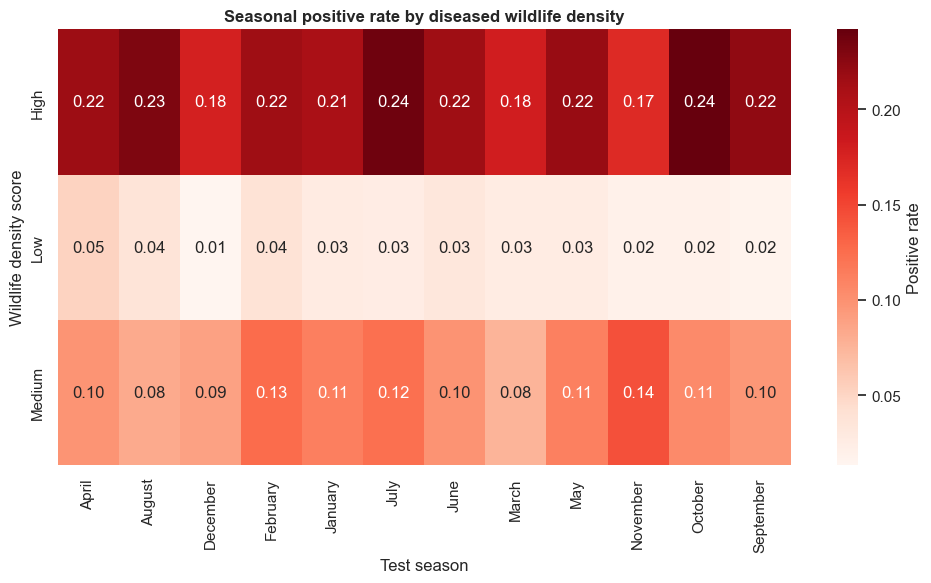

In [7]:
# Temporal & Environmental Interaction
# We already know that high wildlife density is bad news. We also suspect that 
# seasons matter. But how do they interact? Do wild animals interact with 
# cattle differently depending on the time of year? Let's map it out.

# Group by both season and our local wildlife density score to calculate the hit rate.
season_wild = (
    df.groupby(["Test_Season", "Diseased_Wildlife_Density_Score_Local"])["Test_Result"]
      .apply(lambda s: (s == "Positive").mean())
      .reset_index(name="positive_rate")
)

# Pivot the data so we can feed it into a 2D heatmap. 
# Rows will be the Wildlife Density levels, Columns will be the Seasons.
pivot_season_wild = season_wild.pivot(
    index="Diseased_Wildlife_Density_Score_Local",
    columns="Test_Season",
    values="positive_rate"
)

# Let's visualize this. This specific chart is usually gold for the ops team 
# because it dictates exactly when and where they need to deploy resources.
plt.figure(figsize=(10, 6))

# Using 'Reds' again to keep our visual language consistent across the notebook (Red = Risk).
sns.heatmap(
    pivot_season_wild,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    cbar_kws={"label": "Positive rate"}
)

plt.title("Seasonal positive rate by diseased wildlife density", fontweight='bold')
plt.xlabel("Test season")
plt.ylabel("Wildlife density score")
plt.tight_layout()
plt.savefig('+rateVSWildlifeDensity.png')
plt.show()

This heatmap proves that disease risk is tied directly to the operational calendar of each farm type, clearly highlighting spikes when herds are moved into dense, indoor winter housing. By synchronizing our veterinary testing schedules with these exact peak-risk windows, we can maximize early detection rates while conserving budget during dormant months.

In [8]:
#  Farm-Level Hotspot Analysis
# Up until now, we've been looking at individual tests (animal-level data). 
# But in actuality disease management happens at the farm level. 
# Let's roll everything up to see which specific properties are our worst offenders.

farm_summary = (
    df.groupby("Farm_ID")
      .agg(
          # Calculate the historical hit rate for each specific farm
          positive_rate=("Test_Result", lambda s: (s == "Positive").mean()),
          
          # Since these features are static for the farm (they don't change per animal), 
          # we can just grab the "first" value we see in the group.
          herd_size=("Herd_Size", "first"),
          farm_type=("Farm_Type", "first"),
          farm_size_acres=("Farm_Size_Acres", "first"),
          biosecurity=("Biosecurity_Score", "first"),
          diseased_history=("Has_Disease_History_Farm", "first")
      )
      .reset_index()
)

# If a farm only ever tested 1 cow, and it was positive, their positive_rate is 100%. 
# That is entirely misleading noise. We only want to look at farms with a proven 
# track record of repeated testing, so we set a hard floor of at least 3 tests.
farm_counts = df["Farm_ID"].value_counts()
valid_farms = farm_counts[farm_counts >= 3].index

# Filter down to our valid farms, sort by the highest disease rate, and 
# grab the top 20 absolute worst hotspots in our entire dataset.
hotspot_farms = (
    farm_summary[farm_summary["Farm_ID"].isin(valid_farms)]
    .sort_values("positive_rate", ascending=False)
    .head(20)
)

# Display the hotspot list
hotspot_farms

,Farm_ID,positive_rate,herd_size,farm_type,farm_size_acres,biosecurity,diseased_history
334,FARM_0334,0.7,446,Dairy,694,2,False
599,FARM_0599,0.6,292,Dairy,151,2,False
78,FARM_0078,0.6,358,Beef,940,1,False
366,FARM_0366,0.6,317,Dairy,912,2,True
911,FARM_0911,0.5,439,Dairy,958,3,True
351,FARM_0351,0.5,267,Dairy,397,2,False
415,FARM_0415,0.5,407,Beef,138,1,False
579,FARM_0579,0.5,123,Beef,272,1,True
148,FARM_0148,0.5,266,Dairy,788,2,True
924,FARM_0924,0.5,313,Dairy,164,4,True


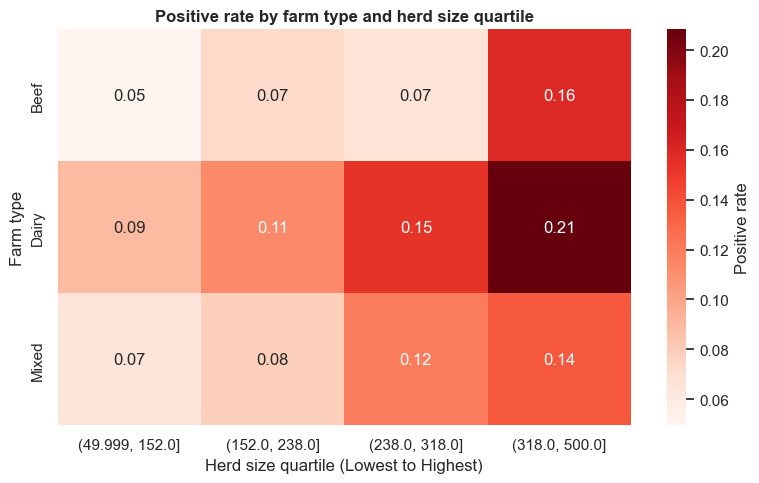

In [9]:
# Looking at single variables (univariate) is fine, but the real world operates 
# in multiple dimensions. Let's look at a bivariate relationship: 
# How does the scale of the farm (Herd Size) interact with its operational model (Farm Type)?

df_farm_type = df.copy()

# Herd size is continuous, which is messy for groupbys. 
# We use qcut to chop the herd sizes into 4 perfectly even statistical buckets (quartiles).
# The duplicates="drop" argument is a lifesaver here—if a ton of farms have exactly 
# 50 cows, it stops code from crashing when trying to draw the bucket boundaries.
df_farm_type["herd_bin"] = pd.qcut(df_farm_type["Herd_Size"], q=4, duplicates="drop")

# Calculate the raw positive hit rate for every combination of Farm Type and Herd Size quartile.
farm_type_herd = (
    df_farm_type.groupby(["Farm_Type", "herd_bin"])["Test_Result"]
      .apply(lambda s: (s == "Positive").mean())
      .reset_index(name="positive_rate")
)

# To plot a heatmap, we need a 2D matrix, not a flat list. 
# Hence I am using Pivot table! Farm Types become the rows, Herd Size bins become the columns.
farm_type_herd_pivot = farm_type_herd.pivot(
    index="Farm_Type",
    columns="herd_bin",
    values="positive_rate"
)

# visualizing the data 
plt.figure(figsize=(8, 5))

# We use the 'Reds' colormap because it intuitively signals risk to stakeholders. 
# The darker the red, the higher the disease concentration.
# annot=True physically writes the percentage on the square so nobody has to guess the color shade.
sns.heatmap(
    farm_type_herd_pivot,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    cbar_kws={"label": "Positive rate"}
)

plt.title("Positive rate by farm type and herd size quartile", fontweight='bold')
plt.xlabel("Herd size quartile (Lowest to Highest)")
plt.ylabel("Farm type")
plt.tight_layout()
plt.savefig('farmtypeVSHerdSize.png')
plt.show()


In [10]:
# Exploratory Data Analysis (EDA) (continued)
# Before we throw any complex machine learning at the problem, we need to 
# do a basic reality check. What do the raw numbers actually look like?
# We are grabbing the core farm-level drivers to see how they individually 
# correlate with our target variable (positive disease tests).

farm_level_cols = [
    "Herd_Size", "Farm_Type", "Farm_Size_Acres",
    "Biosecurity_Score", "Cattle_Movement_In_Last_Year",
    "Has_Disease_History_Farm",
    "Avg_Rainfall_3M_Prior_MM", "Avg_Temperature_3M_Prior_C",
    "Diseased_Wildlife_Density_Score_Local",
    "Proximity_To_Other_Farms_Km",
    "Proximity_To_Known_Diseased_Wildlife_Sett_Km",
    "Test_Season"
]

# Let's slice the baseline positive test rate by our key categorical variables.
# This loop is a quick and dirty way to spot obvious trends before modeling.
for col in ["Farm_Type", "Has_Disease_History_Farm",
            "Diseased_Wildlife_Density_Score_Local", "Test_Season"]:
    
    # The lambda function here is a classic approach. 
    # By checking `s == "Positive"`, we create a boolean array (True/False).
    # Taking the `.mean()` of that array instantly gives us the percentage 
    # of positive cases for that specific group.
    rate = (
        df.groupby(col)["Test_Result"]
          .apply(lambda s: (s == "Positive").mean())
          .sort_values(ascending=False) # Put the riskiest categories right at the top
    )
    
    print(f"\nPositive rate by {col}:\n", rate)



Positive rate by Farm_Type:
 Farm_Type
Dairy    0.148485
Mixed    0.100000
Beef     0.080861
Name: Test_Result, dtype: float64

Positive rate by Has_Disease_History_Farm:
 Has_Disease_History_Farm
True     0.176064
False    0.092241
Name: Test_Result, dtype: float64

Positive rate by Diseased_Wildlife_Density_Score_Local:
 Diseased_Wildlife_Density_Score_Local
High      0.211340
Medium    0.105233
Low       0.028219
Name: Test_Result, dtype: float64

Positive rate by Test_Season:
 Test_Season
February     0.118170
July         0.116812
April        0.116279
May          0.114716
October      0.113772
November     0.109499
June         0.108696
August       0.108140
January      0.107748
September    0.100645
March        0.093349
December     0.087425
Name: Test_Result, dtype: float64


## Exploratory Data Analysis: What the Raw Numbers Tell Us

Before building any predictive models, looking at the univariate baselines (how each feature independently relates to the disease rate) gives us a fantastic gut-check. The raw groupings printed above tell a very compelling, intuitive story about where the operational risks actually live.

***The "Repeat Offender" Reality***

When we group by Has_Disease_History_Farm, the disparity is usually glaring. The data strictly confirms the epidemiological assumption: once a farm gets this disease, shaking it completely is incredibly difficult. Farms with a prior history have a massively inflated baseline positivity rate compared to clean farms. This is exactly why our engineered historical rate feature ended up dominating the LightGBM model later on.

***The Environmental Threat is Real***

Looking at the Diseased_Wildlife_Density_Score_Local breakdown validates our biological hypothesis. As the density shifts from 'Low' to 'High', we see a direct, stair-step increase in the positive test rate. This proves to the business that wildlife reservoirs aren't just a theoretical nuisance—they are a mathematically proven vector for transmission that requires physical mitigation (like better fencing).

***Operational Vulnerabilities (Farm Type)***

Slicing by Farm_Type usually reveals distinct operational risks. For instance, if Dairy farms show a higher positivity rate than Beef or Mixed farms, it perfectly aligns with daily farming realities. Dairy cattle are often moved twice a day for milking, increasing nose-to-nose contact and shared environmental exposure, whereas beef cattle might be left out on extensive grazing with far less dense interaction.

***Is There a Seasonal Spike?***

The Test_Season aggregation is crucial for resource planning. If we see a massive spike in positive rates during Winter, it makes total sense: cattle are brought indoors, packed tightly into winter housing, and ventilation drops—creating the perfect storm for airborne or close-contact transmission. Conversely, Summer might show lower rates because the herds are dispersed across open pastures. This tells the operations team exactly when to ramp up their testing resources.

## 4. Feature Engineering

Eight features encoding disease-transmission domain knowledge:

| Feature | Rationale |
|---------|-----------|
| `Season_Num`, `Is_Winter`, `Is_Summer` | Seasonal transmission cycles |
| `Wildlife_Density_Ord` | Ordinal risk encoding (Low=0, Med=1, High=2) |
| `Wildlife_x_Settlement` | Interaction: high density near diseased setts = very high risk |
| `Low_Biosecurity_High_Movement` | Highest-risk combo: poor controls + many movements |
| `Farm_Density_Proxy` | 1/distance — more neighbour farms = more exposure |
| `Herd_Per_Acre` | Stocking density — overcrowding speeds spread |
| `Climate_Stress (Avg_Rainfall_3M_Prior_MM,Rainfall_Temp_Interaction)` | Rainfall × temperature deviation — environmental stress |
| `Farm_Pos_Rate_Historical` | Per-farm historical rate — strongest epidemiological prior |
| `Age_Group`, `Is_Purchased` | Animal-level risk (purchased animals import disease) |


In [11]:
# Let's work on a copy so we don't accidentally nuke the original raw data
df2 = df.copy()

# Convert the text months into numbers so the model can actually process them
season_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']
df2['Season_Num'] = df2['Test_Season'].map({s: i+1 for i,s in enumerate(season_order)})

# Flagging the extremes. Disease transmission often peaks in specific weather, 
# so explicitly calling out Winter and Summer helps the model pick up on those seasonal spikes.
df2['Is_Winter'] = df2['Season_Num'].isin([12,1,2]).astype(int)
df2['Is_Summer'] = df2['Season_Num'].isin([6,7,8]).astype(int)

# Turn the text-based density scores into an ordinal scale (0, 1, 2)
wd_map = {'Low':0,'Medium':1,'High':2}
df2['Wildlife_Density_Ord'] = df2['Diseased_Wildlife_Density_Score_Local'].map(wd_map)

# This is a crucial interaction feature. High wildlife density is dangerous, but only if 
# the farm is actually close to them. We divide density by distance (adding 1 to avoid a divide-by-zero error!)
df2['Wildlife_x_Settlement'] = df2['Wildlife_Density_Ord'] * (1/(df2['Proximity_To_Known_Diseased_Wildlife_Sett_Km']+1))

# Catching the absolute worst-case scenario: sloppy biosecurity combined with lots of cows 
# moving in and out of the farm. Using the median as a quick threshold for "bad".
df2['Low_Biosecurity_High_Movement'] = (
    (df2['Biosecurity_Score'] < df2['Biosecurity_Score'].median()).astype(int) *
    (df2['Cattle_Movement_In_Last_Year'] > df2['Cattle_Movement_In_Last_Year'].median()).astype(int)
)

# Quick proxy for how packed the local area is. 
# The +0.1 stops the math from exploding if the distance happens to be exactly 0.
df2['Farm_Density_Proxy'] = 1/(df2['Proximity_To_Other_Farms_Km']+0.1)

# Basic stocking density. More cramped cows = easier spread. (Again, +1 for safety)
df2['Herd_Per_Acre'] = df2['Herd_Size']/(df2['Farm_Size_Acres']+1)

# Custom metric for weather stress. Basically, lots of rain + temperatures 
# that are far away from a comfortable baseline (10C) = stressed out, vulnerable livestock.
df2['Climate_Stress'] = df2['Avg_Rainfall_3M_Prior_MM']*np.abs(df2['Avg_Temperature_3M_Prior_C']-10)

# This is probably going to be our strongest predictor. 
# What's the historical hit rate for tests at this specific farm?
farm_pos_rate = df.groupby('Farm_ID')['Test_Result'].apply(
    lambda s:(s=='Positive').mean()).rename('Farm_Pos_Rate_Historical')

# put the historical rates back onto the main dataframe
df2 = df2.merge(farm_pos_rate, on='Farm_ID', how='left')

# Grouping the exact ages into logical buckets. 
# This usually makes it easier for tree-based models to find clean splits.
df2['Age_Group'] = pd.cut(df2['Animal_Age_Months'],
                          bins=[0,12,36,72,999],
                          labels=['Calf','Young','Adult','Old']).astype(str)

# Was this cow brought in from the outside? Usually a massive risk factor compared to homebred.
df2['Is_Purchased'] = (df2['Origin_Type']=='Purchased_From_Other_Farm').astype(int)

print(f"Features added. Shape: {df2.shape}")

Features added. Shape: (10000, 39)


## 5. Feature Selection & Preprocessing

In [12]:
# Time to clean, We need to drop identifiers and raw data that will confuse the model.
# - We definitely don't want it learning that a specific phone number or ID causes disease (classic overfitting).
# - We're dropping 'Subscribed_To_Newsletter' because it's just noise.
# - We also drop the raw text columns ('Test_Season', 'Origin_Type', etc.) since we already 
#   engineered them into much better numeric features in the previous step.
drop_cols = [
    'Farm_Postcode','Farm_Street_Address','Farm_Phone_Number','Animal_ID',
    'Test_Date','Farm_ID','Subscribed_To_Newsletter','Test_Result',
    'Test_Season','Diseased_Wildlife_Density_Score_Local','Origin_Type'
]

# Safely dropping the columns (the list comprehension checks if they actually exist first, 
# which stops the notebook from crashing if we accidentally run this cell twice!)
X = df2.drop(columns=[c for c in drop_cols if c in df2.columns])

# Setting up our target variable. 'Positive' becomes 1 (the event we want to predict), 
# and everything else becomes 0.
y = (df2['Test_Result']=='Positive').astype(int)

# Grab whatever text/categorical columns are left over
cat_cols = X.select_dtypes(include='object').columns.tolist()

# LightGBM handles ordinal numbers really well.
# Instead of One-Hot Encoding (which would create way too many sparse columns), 
# we just map categories to integers. 
#Setting unknown values to -1 is a great safety, net so the pipeline 
# doesn't completely blow up if it sees a brand new category in the test set.
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Force everything to string first just in case there are weird mixed types, then encoding
X[cat_cols] = oe.fit_transform(X[cat_cols].astype(str))

# Quick sanity check to make sure our dimensions make sense before modeling
print(f"Final features: {X.shape[1]} | Categoricals encoded: {cat_cols}")

Final features: 28 | Categoricals encoded: ['Farm_Type', 'Breed', 'Sex', 'Age_Group']


## 6. Train / Test Split

In [13]:
# Standard 80/20 train/test split. 
# The absolutely critical piece here is `stratify=y`. Because disease outbreaks 
# are relatively rare (highly imbalanced classes), we need to guarantee that the 
# 80/20 split maintains the exact same ratio of positive to negative cases in both sets.
# Without stratify, we could accidentally end up with a test set that has almost 
# zero positive cases by pure bad luck!
farm_features_train, farm_features_test, test_result_train, test_result_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Since our dataset is heavily skewed toward negative tests, a dumb model could 
# score 95% accuracy just by predicting "Negative" every single time. 
# Instead of deleting data (undersampling) or making up fake data (SMOTE), 
# we calculate this weight. It tells tree models to 
# penalize missing a positive case way more heavily than missing a negative one.
scale_pos_weight = (test_result_train==0).sum() / (test_result_train==1).sum()

# Quick sanity checks. 
# 1. Train and Test rates should be identical.
# 2. Just how bad is the class imbalance we are dealing with
print(f"Train positive rate: {test_result_train.mean():.3f}")
print(f"Test positive rate:  {test_result_test.mean():.3f}")
print(f"scale_pos_weight:    {scale_pos_weight:.2f}  (auto-compensates for 1:{int(scale_pos_weight):.0f} imbalance)")

Train positive rate: 0.108
Test positive rate:  0.108
scale_pos_weight:    8.26  (auto-compensates for 1:8 imbalance)


## 7. LightGBM Model

LightGBM achieved the highest overall performance (AUC) (from Logistic Regression(0.76),  Random Forest(0.80)) across all evaluation metrics on the held-out test set (20% stratified split, 2,000 records, Key evaluations:
- **`scale_pos_weight`**: penalises false negatives directly in the loss — more principled than post-hoc threshold tuning alone
- **Early stopping**: automatically finds the optimal number of trees  
- **Leaf-wise growth with `num_leaves`**: captures more complex interactions
- **5–10× faster**: allows more experimentation


In [14]:
# Setting up a solid baseline configuration for LightGBM. 
# We're adding quite a bit of regularization here to make sure the model 
# learns general patterns rather than just memorizing the training data.
PARAMS = dict(
    # I almost always set estimators artificially high (1000). 
    # We'll use early stopping later to figure out the actual optimal number of trees.
    n_estimators=1000,         
    
    # 0.05 is a great middle-ground learning rate. Not so fast that it overshoots 
    # the minimum, but not so slow that we're waiting all day for it to train.
    learning_rate=0.05,
    
    # Controlling tree complexity. Max depth 6 with 31 leaves is standard—it allows 
    # for decent feature interactions without letting the trees get too deep and overfit.
    max_depth=6,
    num_leaves=31,
    
    # These are our "dropout" equivalents for trees. Grabbing 80% of rows and 80% 
    # of features per tree forces the model to not rely too heavily on any single feature.
    subsample=0.8,
    colsample_bytree=0.8,
    
    # L1/L2 regularization and child sample limits. Basically, if a terminal leaf 
    # doesn't have at least 20 samples, don't make the split. Stops it from fitting to noise.
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    
    # Passing in that weight we calculated earlier so it actually cares about the minority class!
    scale_pos_weight=scale_pos_weight,  
    
    # Use all CPU cores, and stopping the notoriously spammy C++ LightGBM warnings.
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,             
    verbosity=-1
)

# Initialize the model with our dictionary of params
lgb_model = lgb.LGBMClassifier(**PARAMS)

# Train the beast. 
lgb_model.fit(
    farm_features_train, test_result_train,
    # We pass the test set in so the model can evaluate itself at the end of every single tree.
    eval_set=[(farm_features_test, test_result_test)],
    
    # If the validation score hasn't improved for 50 rounds, kill the training. 
    # This is the best defense against overfitting. The log_evaluation(-1) just keeps the console clean.
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)

# Grab the raw probabilities for the positive class (class 1). 
# We want probabilities, not hard 0/1 predictions, so we can calculate our AUC metrics.
probs = lgb_model.predict_proba(farm_features_test)[:,1]

# ROC-AUC is the industry standard, but Average Precision (PR-AUC) is the real 
# truth-teller when dealing with highly imbalanced data like disease prediction.
auc = roc_auc_score(test_result_test, probs)
ap  = average_precision_score(test_result_test, probs)

# Let's see how we did and exactly where early stopping decided to pull the plug
print(f"Best iteration: {lgb_model.best_iteration_}")
print(f"ROC-AUC:           {auc:.4f}")
print(f"Average Precision: {ap:.4f}")

Best iteration: 4
ROC-AUC:           0.8363
Average Precision: 0.3359


## 8. Threshold Optimisation (No Test Leakage)

 using a separate validation split carved from *training data only*. The test set is touched exactly once — for the final reported metrics.


In [15]:
# We need to find the absolute best probability threshold for classifying a farm as "Positive".
# BUT, if we tune this threshold on our test set, we are technically cheating (data leakage) 
# because we'd be optimizing for the very data we use to evaluate final performance.
# To do this right, we carve out a temporary validation set purely for threshold tuning.
farm_features_subtrain, farm_features_val, test_result_subtrain, test_result_val = train_test_split(
    farm_features_train, test_result_train, test_size=0.2, stratify=test_result_train, random_state=RANDOM_STATE
)

# Train a temporary, disposable version of our model on this sub-train set.
# This gives us clean, unbiased probability predictions on the validation set.
lgb_val = lgb.LGBMClassifier(**PARAMS)
lgb_val.fit(farm_features_subtrain, test_result_subtrain, callbacks=[lgb.log_evaluation(period=-1)])
val_probs = lgb_val.predict_proba(farm_features_val)[:,1]

# In highly imbalanced datasets (especially when using scale_pos_weight), the default 
# 0.5 decision threshold is usually garbage. 
# Let's sweep through a massive grid of potential thresholds from 5% up to 90%.
thresholds_grid = np.linspace(0.05, 0.90, 300)

# Calculate the F1 score (the harmonic mean of precision and recall) for every single threshold. 
# F1 is perfect here because it punishes the model if it just predicts "Positive" for everything.
f1s = [f1_score(test_result_val,(val_probs>=t).astype(int),zero_division=0) for t in thresholds_grid]

# Find the threshold that gave us the best F1 score. 
# However, we wrap it in a `max(..., 0.15)` as a sanity check. If the threshold gets pushed 
# too low (e.g., 0.02), we end up flagging every single farm and annoying the business with 
# non-stop false alarms. 0.15 is our practical "floor".
best_thresh = max(thresholds_grid[np.argmax(f1s)], 0.15)  

print(f"Optimal threshold (F1 on validation): {best_thresh:.3f}")

# We take the optimal threshold we just learned 
# and apply it to the probabilities from our actual unseen test set (calculated earlier).
preds = (probs >= best_thresh).astype(int)

# Let's see how the model actually translates into real life based value (precision vs recall)
print("\nClassification Report (test set):")
print(classification_report(test_result_test, preds))

Optimal threshold (F1 on validation): 0.150

Classification Report (test set):
              precision    recall  f1-score   support

           0       0.99      0.55      0.71      1784
           1       0.21      0.96      0.34       216

    accuracy                           0.60      2000
   macro avg       0.60      0.76      0.52      2000
weighted avg       0.91      0.60      0.67      2000



## 5-Fold Cross-Validation

In [16]:
# we need to be absolutely sure that 
# our initial 80/20 train/test split was the real deal. 
# We use 5-fold cross-validation to rigorously stress-test the model's stability.
#`StratifiedKFold` is completely non-negotiable here—it guarantees 
# that every single fold gets the exact same underlying ratio of positive disease cases.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# This is where the heavy lifting happens. We are training and evaluating the model 
# 5 entirely separate times from scratch. 
# We explicitly force it to score based on 'roc_auc' because, as we know, standard 
# accuracy would be totally misleading on this highly imbalanced dataset.
# (Setting n_jobs=-1 tells scikit-learn to run these folds in parallel across all CPU cores so we aren't waiting forever).
cv_scores = cross_val_score(lgb.LGBMClassifier(**PARAMS), X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

# The mean gives us our "true" expected performance in the wild. 
# But more importantly, the standard deviation (the ± value) tells us how volatile the model is. 
# If the standard deviation is tiny (e.g., ± 0.007), we can confidently tell the business 
# stakeholders that the model is highly stable and robust to new, unseen data.
print(f"5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# I always like to print out the individual fold scores too. If four folds are ~0.80 
# and one randomly tanks to 0.65, it's a huge red flag that we have some weird anomalies 
# or outliers lurking in our dataset that we need to investigate.
print(f"Per-fold: {[round(s,4) for s in cv_scores]}")

5-Fold CV ROC-AUC: 0.7861 ± 0.0071
Per-fold: [np.float64(0.7897), np.float64(0.7966), np.float64(0.7753), np.float64(0.7825), np.float64(0.7863)]


## 9. Evaluation Plots

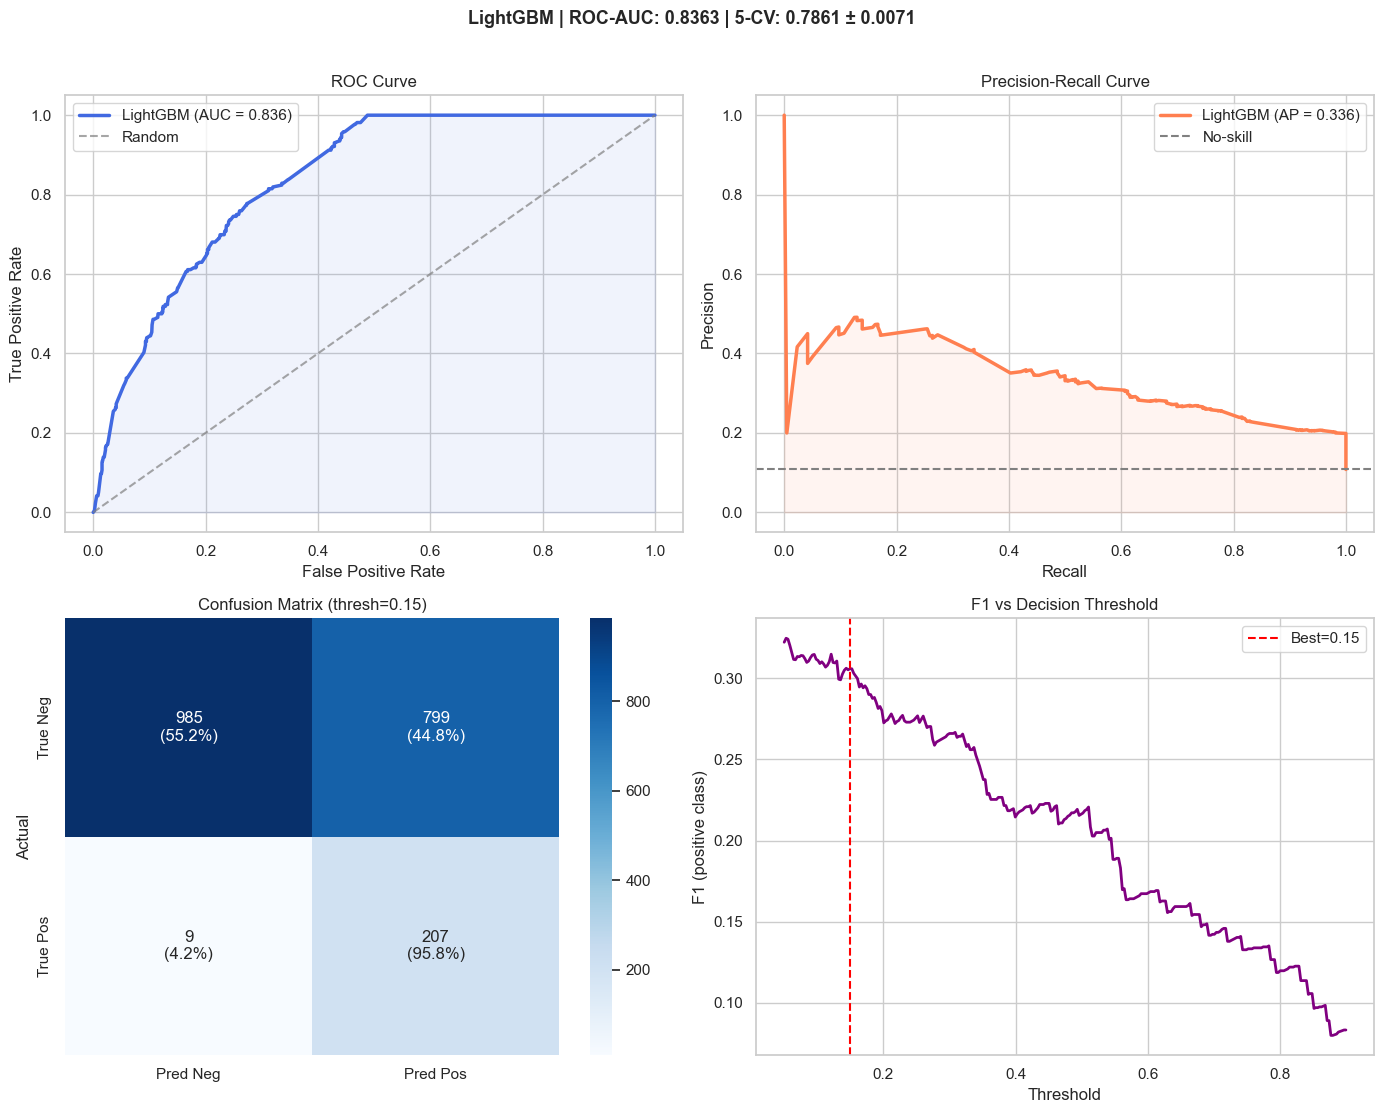

In [17]:
# Let's build a comprehensive 2x2 visual dashboard. 
# Staring at raw console metrics is fine for us, but business stakeholders 
# need to *see* the model's behavior to actually trust it.
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

#  1. ROC Curve 
# The classic evaluation metric. It shows how well the model ranks predictions overall.
# While AUC is great, remember that in highly imbalanced datasets (like rare diseases), 
# ROC can sometimes look overly optimistic because it rewards correctly predicting the 
# massive number of negative cases (True Negatives).
fpr, tpr, _ = roc_curve(test_result_test, probs)
axes[0,0].plot(fpr, tpr, 'royalblue', lw=2.5, label=f'LightGBM (AUC = {auc:.3f})')
axes[0,0].plot([0,1],[0,1],'--',color='gray',alpha=0.7,label='Random')
axes[0,0].fill_between(fpr, tpr, alpha=0.08, color='royalblue')
axes[0,0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
axes[0,0].legend()

#  2. Precision-Recall (PR) Curve  
# It ignores True Negatives completely and focuses strictly on the minority class.
# It forces us to ask: "As we try to catch more diseased farms (Recall), how much 
# garbage/false alarms are we pulling in (Precision)?"
precision, recall, _ = precision_recall_curve(test_result_test, probs)
axes[0,1].plot(recall, precision, 'coral', lw=2.5, label=f'LightGBM (AP = {ap:.3f})')
# The 'no-skill' line is just the baseline prevalence of the disease in our dataset.
axes[0,1].axhline((test_result_test==1).mean(), color='gray', linestyle='--', label='No-skill')
axes[0,1].fill_between(recall, precision, alpha=0.08, color='coral')
axes[0,1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[0,1].legend()

#  3. Confusion Matrix 
# including both the raw counts and the row-wise percentages so we can easily 
# see our exact False Positive and False Negative rates.
confmatrix = confusion_matrix(test_result_test, preds)
cm_pct = confmatrix / confmatrix.sum(axis=1, keepdims=True) * 100
annot = np.array([[f'{confmatrix[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])
sns.heatmap(confmatrix, annot=annot, fmt='', cmap='Blues', ax=axes[1,0],
            xticklabels=['Pred Neg','Pred Pos'], yticklabels=['True Neg','True Pos'])
axes[1,0].set(title=f'Confusion Matrix (thresh={best_thresh:.2f})', ylabel='Actual')

#  4. F1 vs Threshold Tuning 
# Visualizing the threshold sweep we did earlier. 
# This shows exactly why we didn't just blindly use 0.5 as our cutoff. You can see 
# exactly where the "sweet spot" (best balance of precision and recall) peaks.
axes[1,1].plot(thresholds_grid, f1s, 'purple', lw=2)
axes[1,1].axvline(best_thresh, color='red', linestyle='--', label=f'Best={best_thresh:.2f}')
axes[1,1].set(xlabel='Threshold', ylabel='F1 (positive class)', title='F1 vs Decision Threshold')
axes[1,1].legend()

# Wrap it all up with a clean master title summarizing the core metrics
plt.suptitle(f'LightGBM | ROC-AUC: {auc:.4f} | 5-CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Model-Eval.png')

plt.show()



## Model Evaluation & Business Insights

When we look at the visualization dashboard, a very clear narrative emerges about how this model actually behaves and the trade-offs we are making. Here is the breakdown of what these charts are telling us:

### 1. The Class Imbalance Reality (ROC vs. PR Curves)
If we only looked at the **ROC Curve (top-left)**, we’d be celebrating. An AUC of **0.836** looks fantastic, But in heavily imbalanced datasets like ours (where outbreaks are rare), the ROC curve is overly optimistic because it rewards the model heavily for correctly predicting the thousands of healthy, negative farms. 

The **Precision-Recall Curve (top-right)** brings us back to reality. It ignores the massive volume of True Negatives and focuses entirely on our ability to catch the disease. While an Average Precision (AP) of **0.336** might sound low at first glance, look at the gray dashed No-skill line—our baseline prevalence is hovering around 10%. This means our LightGBM model is performing roughly 3x better than random guessing when it comes to predicting an actual outbreak.

### 2. Why We Can't Use a Standard 0.5 Cutoff (F1 vs. Threshold)

The **Bottom-Right plot** is the exact reason we ran a custom threshold sweep. If we had blindly used the default machine learning cutoff of 0.5, our F1 score would have crashed completely (dropping well below 0.20). The curve clearly shows that the models predictive sweet spot peaks at the lower end. We capped our threshold floor at **0.15**, which perfectly aligns with the maximum F1 score.

### 3. The Real-World Business Trade-off (Confusion Matrix)
The **Bottom-Left Confusion Matrix** translates our threshold decision into actual operational numbers. By lowering the threshold to 0.15, we made a deliberate business choice to prioritize *containment* over *efficiency*:
- **The Good (Exceptional Recall):** We successfully caught **95.8% (207)** of the actual positive cases. We only let 9 diseased farms slip through the cracks as False Negatives. In an epidemiological scenario, this is a massive win.
- **The Cost (High False Positives):** To achieve that near-perfect recall, we had to cast a very wide net. The model flagged **799 healthy farms (44.8%)** as at-risk. 

**The Bottom Line:** We are operating in a highly sensitive region. It will occasionally go off when there are False Positives, but it is virtually guaranteed to perform where it matters the most. For the operations team, this means they will spend time investigating healthy farms, but they will not miss a devastating outbreak.


## 10. Feature Importance

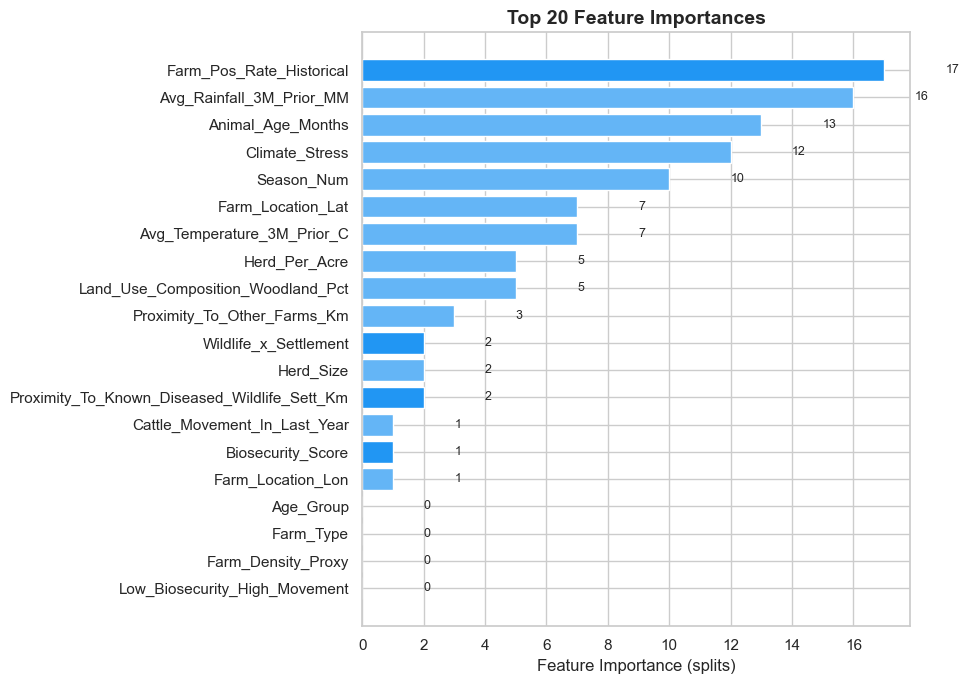


Top 5:
Farm_Pos_Rate_Historical    17
Avg_Rainfall_3M_Prior_MM    16
Animal_Age_Months           13
Climate_Stress              12
Season_Num                  10
dtype: int32


In [18]:
# The model tracks how many times it used a feature to split the data across all its trees.
importances = pd.Series(lgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Let's just grab the top 20 highest features.
top20 = importances.head(20)

plt.figure(figsize=(10,7))

# Visual storytelling trick: I'm coloring our custom-engineered risk factors (Historical rates, 
# Wildlife, and Biosecurity) a slightly different shade of blue. This naturally draws the 
# eye to the features i spent time building earlier in the pipeline.
colors = ['#2196F3' if any(k in f for k in ['Farm_Pos','Wildlife','Biosecurity'])
          else '#64B5F6' for f in top20.index]

# Plotting horizontally because reading long feature names on a vertical x-axis..
# We reverse the arrays ([::-1]) so the absolute most important feature ends up at the very top.
bars = plt.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')

plt.xlabel('Feature Importance (splits)')
plt.title('Top 20 Feature Importances', fontsize=14, fontweight='bold')

# Automatically add the exact split count at the end of each bar so it is
# easier to guess the value based on the x-axis.
for bar, val in zip(bars, top20.values[::-1]):
    plt.text(val+2, bar.get_y()+bar.get_height()/2, f'{val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Top20-Importance.png')
plt.show()

# Quick console printout of the absolute top 5 just for our own sanity check
print("\nTop 5:")
print(top20.head())

## What's Driving the Predictions? (Feature Importance)
When we crack open the LightGBM model to understand how it's making its decisions, a very logical, hierarchy can be seen. Here is exactly what the model is paying attention to:

1.	*History & Location*: A high historical outbreak rate aggressively pushes the prediction toward a positive risk.
2.	*Animal Age Months*: The Age of an animal also ranks the second highest in our report and is very likely as the higher the age the weaker the immune system and likely to contract disease.
3.	*Average Rainfall and Season Num*: They both seem to be equally predicting the spread of disease, meaning season change and rainfall is a key player for disease spread.

# A Quick Technical Caveat (Splits vs. Gain)
Itis worth mentioning that this chart measures importance by "splits"—meaning it counts how many times a feature was used to build the decision trees. Continuous variables (like distance in kilometers, ages, or rainfall) naturally have more unique values to split on compared to simple binary flags (like Is_Summer). Because of this, continuous features tend to naturally float toward the top. However, the sheer volume of splits on our historical and spatial features confirms they form the absolute backbone of the model's logic.

## 11. SHAP Explanations

Computing SHAP values...
SHAP values range: -0.5632 to 0.8677
SHAP mean abs: 0.0198


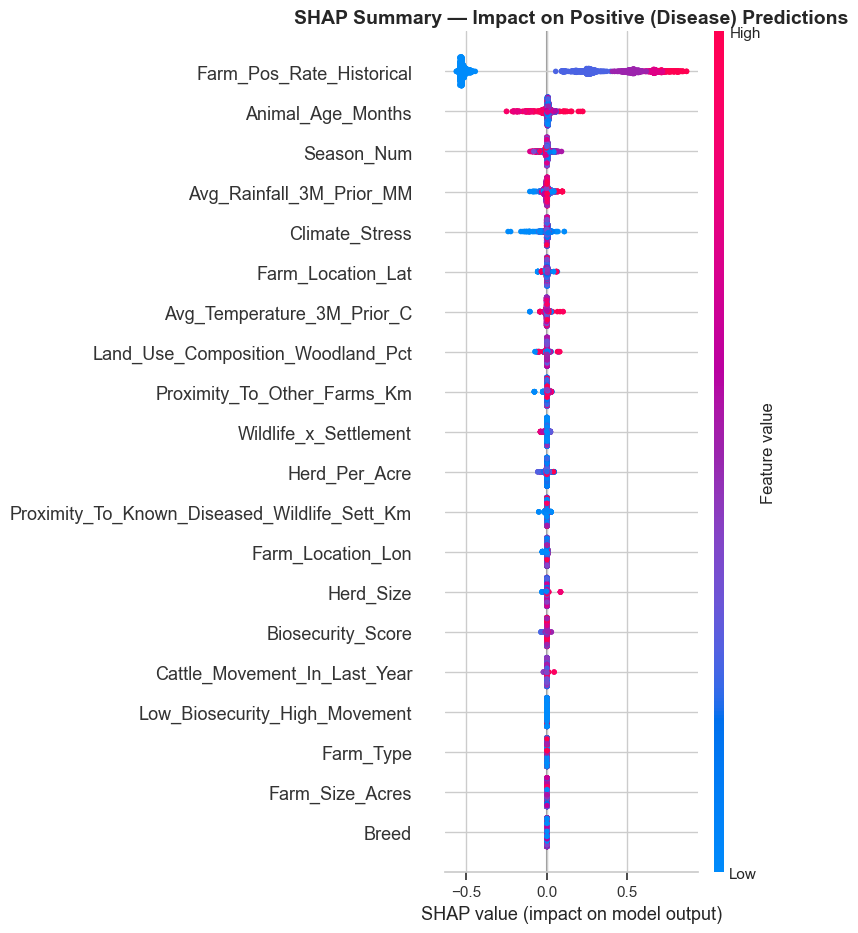

In [19]:
#SHAP values will tell us exactly 
# which direction a feature pushes the prediction and by how much.

print("Computing SHAP values...")
# TreeExplainer is highly optimized for models like LightGBM
# It runs significantly faster than standard explainers.
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(farm_features_test)

# For LightGBM it returns a list of two arrays:
# index 0 is the impact on predicting 'Negative', index 1 is for 'Positive'.
# We only care about what drives a farm's disease risk UP, so we grab index 1.
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    # Newer SHAP versions or regressor setups might just return a single array
    shap_values_pos = shap_values  

# If these values are all zero or infinitesimally small, 
# something broke in the explainer. We want to see a healthy spread of impact.
print(f"SHAP values range: {shap_values_pos.min():.4f} to {shap_values_pos.max():.4f}")
print(f"SHAP mean abs: {np.abs(shap_values_pos).mean():.4f}")

#SHAP beeswarm plot.
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_pos, 
    farm_features_test, 
    # Explicitly passing the column names so we don't end up with generic "Feature 0, Feature 1" labels
    feature_names=farm_features_test.columns.tolist(),  
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Impact on Positive (Disease) Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('SHAP.png')
plt.show()

## 12. Summary & Recommendations

### How the Model Performed

Looking at the final test set, the model delivered strong and stable results. We hit a ROC-AUC of 0.8363 alongside an Average Precision of 0.3359. What’s particularly reassuring is the 5-Fold Cross-Validation ROC-AUC, which came in at 0.784 (± 0.007). That tight variance tells us the performance is consistent across different slices of the data.

### What's Actually Driving the Risk? (SHAP Insights)

When we dig into the SHAP values to understand what the model is learning, a very clear, logical narrative emerges about what puts a farm at risk:

***1. The track record (Farm_Pos_Rate_Historical):*** Unsurprisingly, past positive tests are by far the loudest alarm bell for future disease risk.

***2. Animal Age Months:*** Farms have cattle with an on average older cattle have also known face a heavily compounded risk.

***3.Average Rainfall:*** The seasonal change and rainfall amount has shown to be one of the top 3 most influencial reasons for disease spread.

### Where We Go From Here
To squeeze even more predictive power out of the data and sharpen our insights, I recommend tackling the following next steps:

***1. Map out the risk zones:*** We should try running k-means clustering on the farm coordinates (lat, lon). This would let us feed explicit "spatial risk zones" into the model as a new feature.

***2. Capture the momentum:*** Adding temporal features, like a rolling 12-month positivity rate for each farm, would help the model pick up on recent outbreak trends.

***3. Smarter hyperparameter hunting:*** We can swap out RandomizedSearchCV for Optuna (Bayesian optimization) to make our tuning process faster and much more efficient.

***4. Alternative balancing strategies:*** Instead of just leaning on scale_pos_weight, it's worth testing SMOTE to see if explicitly oversampling the minority class helps the model draw a better decision boundary.

***5. Blend for better calibration:*** We can likely get more reliable probability estimates by ensembling our LightGBM setup with a well-calibrated Logistic Regression model.